In [2]:
import sys
import optuna
import numpy as np
import pandas as pd
from itertools import combinations

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask
from databricks_connector import get_table

pd.set_option('display.max_columns', None)
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"


# features = [
#  'goalNoGoal_chance_goal',
#  'goalNoGoal_chance_goalHome',
#  'goalNoGoal_chance_goalAway',
#  'goalNoGoal_multigoal_m13',
#  'goalNoGoal_multigoal_m14',
#  'goalNoGoal_multigoal_m24',
#  'goalNoGoal_multigoal_m13Home',
#  'goalNoGoal_multigoal_m13Away',
#  'goalNoGoal_multigoal_m24Home',
#  'goalNoGoal_multigoal_m24Away',
#  'goalNoGoal_quote_realGG',
#  'goalNoGoal_quote_initialGG',
#  'goalNoGoal_quote_initialNG',
#  'goalNoGoal_quote_currentGG',
#  'goalNoGoal_quote_currentNG',
#  'goalNoGoal_quote_diffRealCurrGG',
#  'goalNoGoal_quote_diffRealCurrNG',
#  'goalNoGoal_quote_diffInitialCurrGG',
#  'goalNoGoal_quote_diffInitialCurrNG',
#  'goalNoGoal_comparison_affini',
#  'goalNoGoal_comparison_flashback',
#  'goalNoGoal_stats_avgGoalHome',
#  'goalNoGoal_stats_avgGoalTakenHome',
#  'goalNoGoal_stats_avgGoalAway',
#  'goalNoGoal_stats_avgGoalTakenAway',
#  'goalNoGoal_flashback_goal',
#  'goalNoGoal_flashback_m13',
#  'goalNoGoal_flashback_m24',
#  'goalNoGoal_flashback_m35',
#  'underOver_chance_over05HT',
#  'underOver_chance_over052HT',
#  'underOver_chance_over15HT',
#  'underOver_chance_over15',
#  'underOver_chance_over25',
#  'underOver_chance_over35',
#  'underOver_chance_over45',
#  'underOver_quote_realO',
#  'underOver_quote_initialU',
#  'underOver_quote_initialO',
#  'underOver_quote_currentU',
#  'underOver_quote_currentO',
#  'underOver_quote_diffRealCurrU',
#  'underOver_quote_diffRealCurrO',
#  'underOver_quote_diffInitialCurrU',
#  'underOver_quote_diffInitialCurrO',
#  'underOver_comparison_affini',
#  'underOver_comparison_flashback',
#  'underOver_flashback_under05HT',
#  'underOver_flashback_over05HT',
#  'underOver_flashback_under15',
#  'underOver_flashback_over15',
#  'underOver_flashback_under25',
#  'underOver_flashback_over25',
#  'underOver_flashback_under35',
#  'underOver_flashback_over35',
#  'evaluation_valScala',
#  'evaluation_valMetrica',
#  'chance1x2_quote_current1',
#  'chance1x2_quote_current2'
#  ]


features = ["underOver_chance_over15HT",
"chance1x2_quote_current1",
"chance1x2_quote_current2",
"goalNoGoal_quote_currentGG",
"goalNoGoal_chance_goal",
"goalNoGoal_flashback_goal",
"goalNoGoal_stats_avgGoalHome",
"goalNoGoal_stats_avgGoalTakenAway",
"goalNoGoal_stats_avgGoalTakenHome",
"goalNoGoal_stats_avgGoalAway"]

In [ ]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate


In [4]:
# Load data
from etl_pipeline_local import get_btts_table

df_loaded = get_btts_table()

df_loaded = df_loaded.sort_values('time').reset_index(drop=True)

# Train/test split
df = df_loaded.copy()
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1)

# Adding week column 
df["week"] = df["time"].dt.to_period("W")
monday_start = df["time"].min() - pd.to_timedelta(df["time"].min().weekday(), unit="D")
df["week"] = ((df["time"] - monday_start).dt.days // 7) + 1


df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

In [7]:
# Define features and relative step
feature_bins_map = {
    "underOver_chance_over15HT": 5, # 5,
    # "underOver_comparison_affini": 1000, #0.5, #0.1,
    # "underOver_comparison_flashback": 500, #0.5, #0.1,
    # "goalNoGoal_chance_goal": 5, # ,
    "goalNoGoal_flashback_goal": 5, # 5,
    "goalNoGoal_stats_avgGoalHome": 0.5, #0.1, 
    "goalNoGoal_stats_avgGoalTakenAway": 0.5, #0.1, 
    "goalNoGoal_stats_avgGoalTakenHome": 0.5, #0.1, 
    "goalNoGoal_stats_avgGoalAway": 0.5, #0.1, 
    "goalNoGoal_quote_currentGG": 0.1, #0.5, #0.1,
    "evaluation_valScala": None, # se la feature è categorica, mettere None
    "evaluation_valMetrica": None, # se la feature è categorica, mettere None,
    # "chance1x2_quote_current1": 0.2,
    # "chance1x2_quote_current2": 0.2,

 }

# Create the binned dataframe
df_train_binned = df_train.copy()

    
for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: underOver_chance_over15HT
Search space: <IntegerArray>
[15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
Length: 12, dtype: Int64


Feature: goalNoGoal_flashback_goal
Search space: <IntegerArray>
[30, 35, 40, 45, 50, 55, 60, 65, 70, <NA>]
Length: 10, dtype: Int64


Feature: goalNoGoal_stats_avgGoalHome
Search space: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]


Feature: goalNoGoal_stats_avgGoalTakenAway
Search space: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


Feature: goalNoGoal_stats_avgGoalTakenHome
Search space: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  5. ]


Feature: goalNoGoal_stats_avgGoalAway
Search space: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  5. ]


Feature: goalNoGoal_quote_currentGG
Search space: [1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.8 3.  3.2
 3.4 3.5]


Feature: evaluation_valScala
Search space: ['48727' '49657' '49867' '50827' '<NA>']


Feature: evaluation_valMetrica
Search space: ['114521' '147930' '221599' '225586'

In [8]:
min_obs = 50

def objective(trial):
    mask = pd.Series(True, index=df_train_binned.index)

    for feat, step in feature_bins_map.items():

        s = df_train_binned[feat]
        non_null = s.dropna()

        if non_null.empty:
            continue

        # ---------------------------------
        # CASO 1: variabile categorica
        # ---------------------------------
        if not step:
            categorical_set = [
                list(c) for r in range(1, len(s.unique()) + 1)
                for c in combinations(s.unique(), r)
            ]
            categorical_feat = trial.suggest_categorical(f"{feat}_cat", categorical_set)

        # ---------------------------------
        # CASO 2: numerica continua/intera
        # ---------------------------------
        else:
            # TODO: se la feature ha valori nulli, introduco include_missing feature, valutare rimozione  
            if s.isna().sum() > 0:
                include_missing = trial.suggest_categorical(
                    f"{feat}_include_missing",
                    [True, False]
                )

            # TODO: vincolo per >=, <=, <,>, da studiare
            use_min = trial.suggest_categorical(f"{feat}_use_min", [True, False])
            use_max = trial.suggest_categorical(f"{feat}_use_max", [True, False])

            # TODO: questo dovrebbe forzare l'utilizzo della feature, da capire se forzarlo è utile o meno
            # # almeno un vincolo deve essere attivo
            if not use_min and not use_max:
                raise optuna.TrialPruned()
            
            if pd.api.types.is_integer_dtype(s):
                feat_min = trial.suggest_int(
                    name=f"{feat}_min",
                    low=int(non_null.min()),
                    high=int(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_int(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=int(non_null.max()), 
                    step=step
                )
            else:
                feat_min = trial.suggest_float(
                    name=f"{feat}_min",
                    low=float(non_null.min()),
                    high=float(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_float(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=float(non_null.max()),
                    step=step
                )

        # costruzione maschera feature
        feat_mask = pd.Series(True, index=s.index)

        if not step:
            # Categorical filtering
            feat_mask &= s.isin(categorical_feat)
        else:
            # Numerical filtering
            if use_min:
                feat_mask &= s >= feat_min

            if use_max:
                feat_mask &= s <= feat_max

            # Filtering for feature with nan
            if s.isna().sum() > 0:
                if include_missing:
                    feat_mask = feat_mask | s.isna()
                else:
                    feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    selected = df_train_binned.loc[mask]

    if len(selected) < min_obs:
        return -1e9

    mean_return = selected["return"].mean()
    mean_weekly_return = selected.groupby("week")["return"].sum().mean() # massimizzo ritorno settimanale
    std_weekly_return = selected.groupby("week")["return"].sum().std(ddof=0) # minimizzo volatilità ritorno settimanale
    mean_weekly_counts = selected.groupby("week")["return"].sum().mean() # massimizzo counts settimanali
    std_weekly_counts = selected.groupby("week")["return"].count().std(ddof=0) # minimizzo volatilità dei counts settimanali

    # Score 1: caso semplice 
    # score = mean_return * np.sqrt(len(selected))

    # Score 2: tiene conto di volatilità e numero counts. log1p premia i counts in maniera decrescente col volume
    # lam = 0.3
    # score = mean_weekly_return / (std_weekly_return + 1e-6) + lam * np.log1p(mean_weekly_counts / (std_weekly_counts + 1e-6))

    # Score 3: tiene conto di volatilità e numero counts, parametrica. log1p premia i counts in maniera decrescente col volume
    score = mean_weekly_return - 0.5 * std_weekly_return + 0.2 * np.log1p(mean_weekly_counts) - 0.1 * std_weekly_counts

    return float(score)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-03-29 16:43:40,376] A new study created in memory with name: no-name-d0f777ac-5850-484e-87b9-630506e737ba
[I 2026-03-29 16:43:40,380] Trial 0 pruned. 
[I 2026-03-29 16:43:40,394] Trial 1 finished with value: -1000000000.0 and parameters: {'underOver_chance_over15HT_use_min': True, 'underOver_chance_over15HT_use_max': False, 'underOver_chance_over15HT_min': 60, 'underOver_chance_over15HT_max': 70, 'goalNoGoal_flashback_goal_include_missing': False, 'goalNoGoal_flashback_goal_use_min': True, 'goalNoGoal_flashback_goal_use_max': True, 'goalNoGoal_flashback_goal_min': 35, 'goalNoGoal_flashback_goal_max': 50, 'goalNoGoal_stats_avgGoalHome_use_min': True, 'goalNoGoal_stats_avgGoalHome_use_max': True, 'goalNoGoal_stats_avgGoalHome_min': 2.5, 'goalNoGoal_stats_avgGoalHome_max': 4.5, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.5, 'goalNoGoal_stats_avgGoalTakenAway_max': 2.0, 'goalNoGoal_

Best params: {'underOver_chance_over15HT_use_min': True, 'underOver_chance_over15HT_use_max': False, 'underOver_chance_over15HT_min': 45, 'underOver_chance_over15HT_max': 60, 'goalNoGoal_flashback_goal_include_missing': True, 'goalNoGoal_flashback_goal_use_min': True, 'goalNoGoal_flashback_goal_use_max': False, 'goalNoGoal_flashback_goal_min': 40, 'goalNoGoal_flashback_goal_max': 55, 'goalNoGoal_stats_avgGoalHome_use_min': False, 'goalNoGoal_stats_avgGoalHome_use_max': True, 'goalNoGoal_stats_avgGoalHome_min': 0.5, 'goalNoGoal_stats_avgGoalHome_max': 3.5, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': False, 'goalNoGoal_stats_avgGoalTakenAway_min': 2.5, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.5, 'goalNoGoal_stats_avgGoalTakenHome_use_min': True, 'goalNoGoal_stats_avgGoalTakenHome_use_max': False, 'goalNoGoal_stats_avgGoalTakenHome_min': 0.0, 'goalNoGoal_stats_avgGoalTakenHome_max': 1.5, 'goalNoGoal_stats_avgGoalAway_use_min': False, '

In [9]:
# Create the test binned dataframe
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
params_dict =study.best_params

def get_mask(df, params_dict):
    mask = pd.Series(True, index=df.index)

    features = set()
    for key in params_dict:
        for suffix in ["_cat", "_use_min", "_use_max", "_min", "_max", "_include_missing"]: # ,   "_min_idx", "_max_idx", 
             if key.endswith(suffix):
                features.add(key[:-len(suffix)])
                break

    for feat in features:
        s = df[feat]

        include_missing = params_dict.get(f"{feat}_include_missing", False)
        use_min = params_dict.get(f"{feat}_use_min", True)
        use_max = params_dict.get(f"{feat}_use_max", True)

        feat_mask = pd.Series(True, index=df.index)

        # Categorical filtering
        if f"{feat}_cat" in params_dict:
            feat_mask &= s.isin(params_dict[f"{feat}_cat"])

        # Numerical filtering
        if f"{feat}_min" in params_dict and use_min:
            feat_mask &= s >= params_dict[f"{feat}_min"]

        if f"{feat}_max" in params_dict and use_max:
            feat_mask &= s <= params_dict[f"{feat}_max"]

        # if f"{feat}_min_idx" in params_dict and use_min:
        #     feat_mask &= s >= params_dict[f"{feat}_min_idx"]

        # if f"{feat}_max_idx" in params_dict and use_max:
        #     feat_mask &= s <= params_dict[f"{feat}_max_idx"]

        if include_missing:
            feat_mask = feat_mask | s.isna()
        else:
            feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    return mask


train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]

In [10]:
mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: 0.30813186813186816
Accuracy: 0.8 (73/91)


In [11]:
mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: -0.3333333333333333
Accuracy: 0.3 (2/6)


# Plots

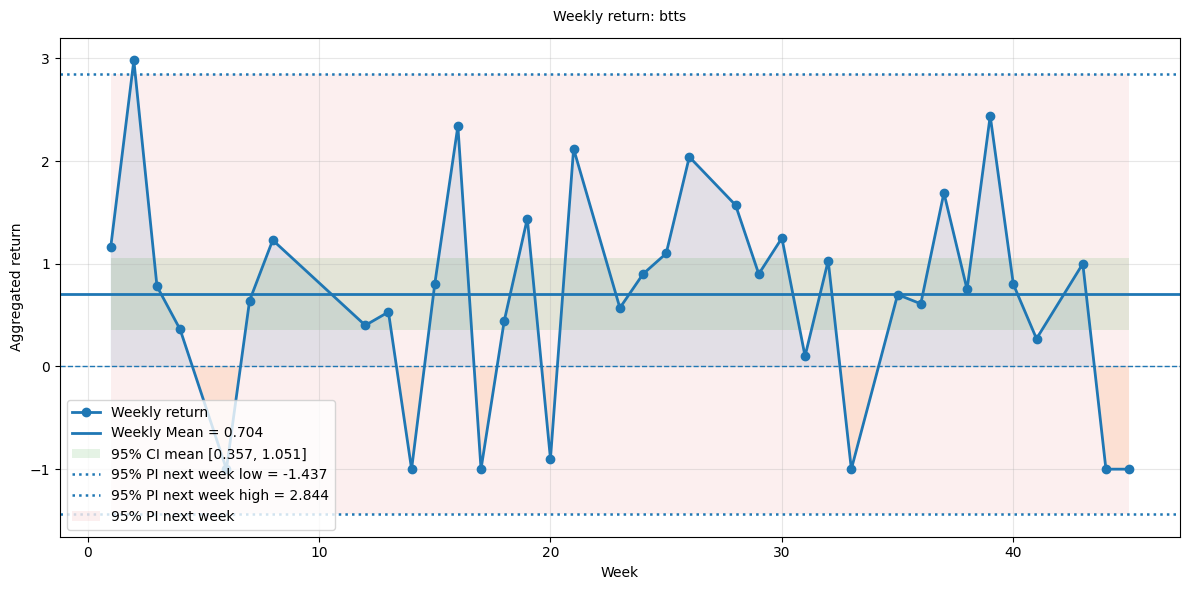

In [12]:
sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [13]:
weekly_return

week
1     1.16
2     2.98
3     0.78
4     0.36
6    -1.00
7     0.64
8     1.23
12    0.40
13    0.53
14   -1.00
15    0.80
16    2.34
17   -1.00
18    0.44
19    1.44
20   -0.90
21    2.12
23    0.57
24    0.90
25    1.10
26    2.04
28    1.57
29    0.90
30    1.25
31    0.10
32    1.03
33   -1.00
35    0.70
36    0.61
37    1.69
38    0.75
39    2.44
40    0.80
41    0.27
43    1.00
44   -1.00
45   -1.00
Name: return, dtype: float64

In [14]:
get_best_strategies(df_tot_filtered)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,0.70,1.04,2.16,1.78,97,0.73


In [16]:
97/45

2.1555555555555554